# Fill Utilities

Foundry tape-outs typically require a **metal/poly fill** step: small dummy
shapes are tiled over the floorplan to improve CMP (chemical-mechanical
planarisation) uniformity.  kfactory's `kf.fill` module wraps KLayout's
`TilingProcessor`-based fill engine into a single high-level call.

| Function | Purpose |
|---|---|
| `kf.fill.fill_tiled` | Tile a fill cell over layer-defined or explicit regions, with per-layer or explicit exclusions |

**Key rules**

* Call `fill_tiled` **inside** the `@kf.cell` function so the target cell is
  still unlocked.  Calling it on a cached (locked) cell raises `LockedError`.
* `fill_layers` / `fill_regions` define *where to place* fill.
* `exclude_layers` / `exclude_regions` define *where not to place* fill.
* The second element of every `(layer, margin)` tuple is a keepout distance
  in **µm** expanded around that layer's shapes.
* `x_space` / `y_space` set the gap between adjacent fill-cell bounding
  boxes; both are in **µm**.

## Setup

In [1]:
import kfactory as kf
from kfactory.utils.fill import fill_tiled


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    FILL: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    METAL: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Fill Cell

A fill cell is any ordinary `KCell`.  Make it small and symmetric so it
tiles cleanly.  Here we use a 1 µm × 1 µm square centred on the origin.

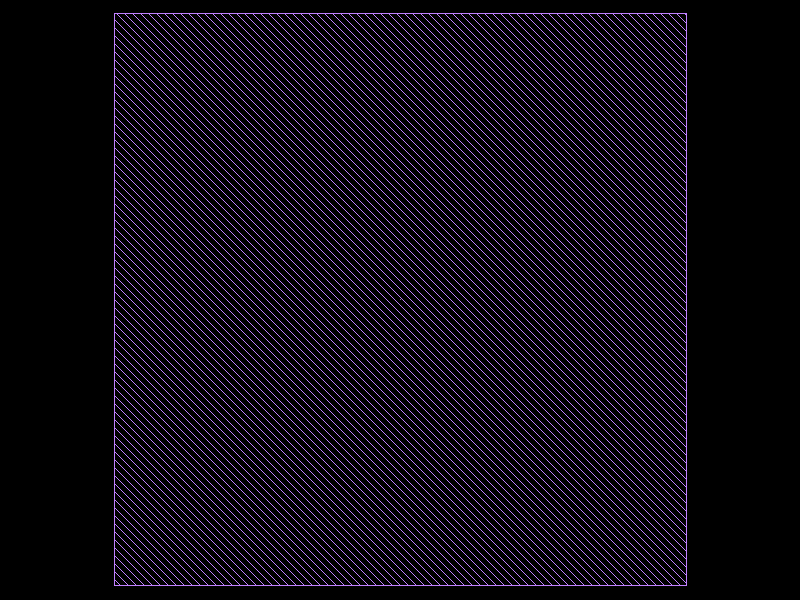

In [2]:
@kf.cell
def fill_dot() -> kf.KCell:
    c = kf.KCell()
    c.shapes(kf.kcl.find_layer(L.FILL)).insert(kf.kdb.DBox(-0.5, -0.5, 0.5, 0.5))
    return c


fill_dot()

## 2 · Basic Layer Fill

Pass `fill_layers` to fill every polygon on a given layer.  The second
element of the tuple is the keepout in µm expanded around those shapes
**before** the fill region is computed (use `0` for no keepout on the
fill layer itself).

`exclude_layers` works the same way for shapes that must *not* be covered.
A keepout of `2.0` µm means fill cells whose bounding box would overlap
within 2 µm of a waveguide edge are suppressed.

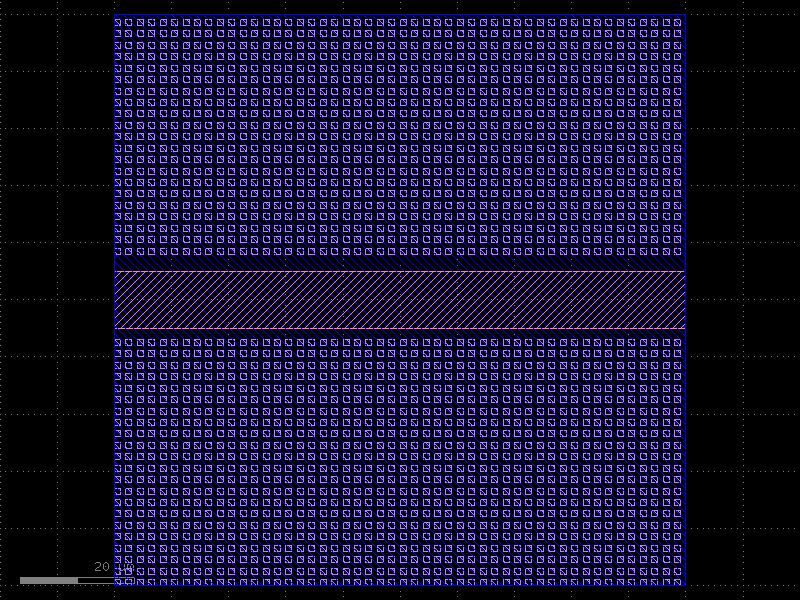

In [3]:
@kf.cell
def chip_basic() -> kf.KCell:
    c = kf.KCell()
    # 100 µm × 100 µm floorplan
    c.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(kf.kdb.DBox(0, 0, 100, 100))
    # Horizontal waveguide through the middle — must stay clear of fill
    c.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(0, 45, 100, 55))

    fill_tiled(
        c,
        fill_dot(),
        fill_layers=[
            (L.FLOORPLAN, 0)
        ],  # fill inside FLOORPLAN; 0 µm keepout on the layer itself
        exclude_layers=[(L.WG, 2.0)],  # keep 2 µm clear of WG edges
        x_space=1.0,  # 1 µm gap between fill cells in X
        y_space=1.0,  # 1 µm gap between fill cells in Y
    )
    return c


chip_basic()

## 3 · Explicit Region Fill

Instead of relying on layer shapes you can pass a `kdb.Region` directly via
`fill_regions`.  This is useful when the fill boundary is computed
programmatically rather than stored on a layer.

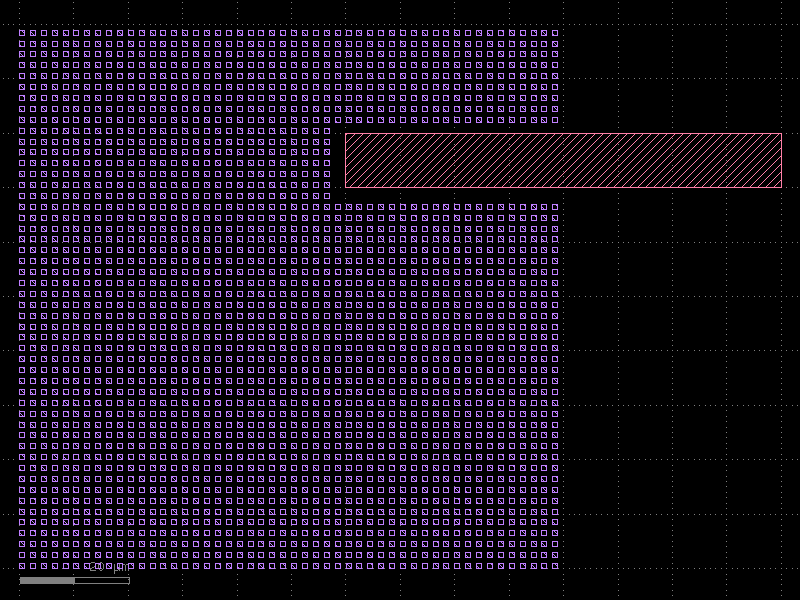

In [4]:
@kf.cell
def chip_region() -> kf.KCell:
    c = kf.KCell()
    # Waveguide on WG layer — must stay clear
    c.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(10, 20, 90, 30))

    # Build an explicit fill region: a 100 µm square in DBU
    fill_region = kf.kdb.Region(kf.kdb.Box(kf.kcl.to_dbu(100), kf.kcl.to_dbu(100)))

    fill_tiled(
        c,
        fill_dot(),
        fill_regions=[(fill_region, 0)],  # (region, keepout µm)
        exclude_layers=[(L.WG, 1.5)],
        x_space=1.0,
        y_space=1.0,
    )
    return c


chip_region()

## 4 · Custom Step Vectors

By default fill cells are placed on a rectangular grid aligned to the fill
cell's bounding box.  Pass `row_step` and `col_step` as `kdb.DVector`
objects (in **µm**) for a custom pitch.

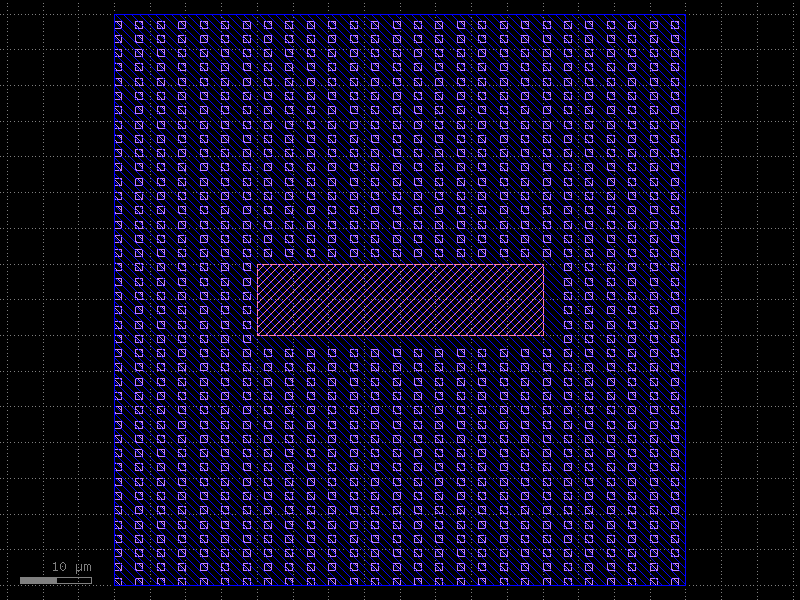

In [5]:
@kf.cell
def chip_custom_pitch() -> kf.KCell:
    c = kf.KCell()
    c.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(kf.kdb.DBox(0, 0, 80, 80))
    c.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(20, 35, 60, 45))

    fill_tiled(
        c,
        fill_dot(),
        fill_layers=[(L.FLOORPLAN, 0)],
        exclude_layers=[(L.WG, 1.0)],
        # 3 µm pitch in X, 2 µm pitch in Y
        row_step=kf.kdb.DVector(3.0, 0),
        col_step=kf.kdb.DVector(0, 2.0),
    )
    return c


chip_custom_pitch()

## 5 · Multiple Exclusion Layers

Pass multiple `(layer, keepout)` pairs to `exclude_layers`.  Each layer can
have a different keepout distance.

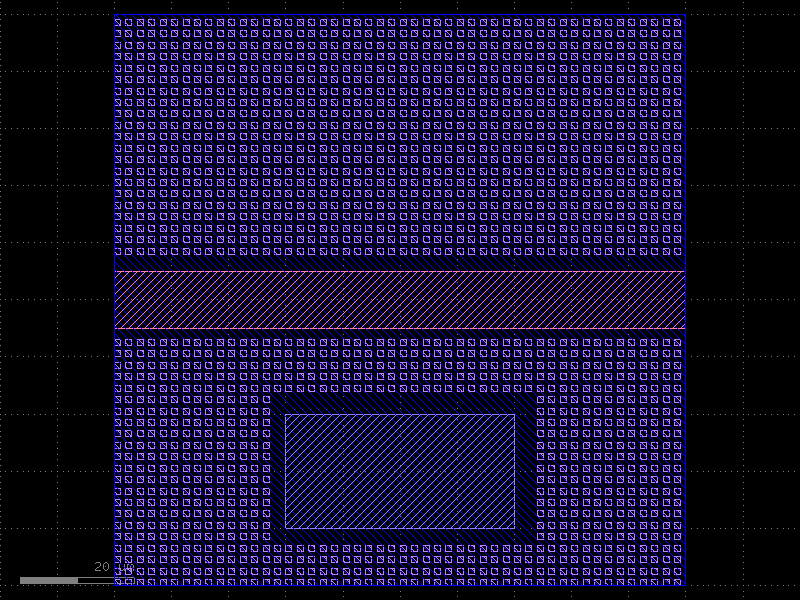

In [6]:
@kf.cell
def chip_multi_excl() -> kf.KCell:
    c = kf.KCell()
    c.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(kf.kdb.DBox(0, 0, 100, 100))
    # Horizontal waveguide
    c.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(0, 45, 100, 55))
    # Metal pad — needs a wider keepout than the waveguide
    c.shapes(kf.kcl.find_layer(L.METAL)).insert(kf.kdb.DBox(30, 10, 70, 30))

    fill_tiled(
        c,
        fill_dot(),
        fill_layers=[(L.FLOORPLAN, 0)],
        exclude_layers=[
            (L.WG, 2.0),  # 2 µm keepout around waveguides
            (L.METAL, 3.0),  # 3 µm keepout around metal pads
        ],
        x_space=1.0,
        y_space=1.0,
    )
    return c


chip_multi_excl()

## API Summary

```python
kf.fill.fill_tiled(
    c,                               # target KCell (must be unlocked)
    fill_cell,                       # cell to tile
    fill_layers  = [(layer, um)],    # layer-defined fill regions
    fill_regions = [(region, um)],   # explicit kdb.Region fill regions
    exclude_layers  = [(layer, um)], # layers to keep clear
    exclude_regions = [(region, um)],# explicit regions to keep clear
    x_space = 0,      # µm gap between fill cells in X
    y_space = 0,      # µm gap between fill cells in Y
    row_step = None,  # kdb.DVector (µm); default = fill_cell width + x_space
    col_step = None,  # kdb.DVector (µm); default = fill_cell height + y_space
    tile_size = None, # (w, h) µm; default = 100× fill-cell pitch
    tile_border = (20, 20),  # µm border around each tile for exclusion look-up
    n_threads = None, # defaults to kf.config.n_threads (all logical CPUs)
    multi = False,    # use fill_region_multi strategy (no origin alignment)
)
```

> **Note:** `fill_tiled` modifies the target cell **in-place** and returns
> `None`.  It must be called while the cell is unlocked, i.e. inside its
> `@kf.cell`-decorated factory function.

## See Also

| Topic | Where |
|-------|-------|
| DRC violation fixing | [Utilities: DRC Fix](drc_fix.py) |
| Boolean / region operations | [Core Concepts: Geometry](../concepts/geometry.py) |
| Cell-level enclosures | [Enclosures: KCell Enclosure](../enclosures/kcell_enclosure.py) |
| Array / grid layout | [Utilities: Grid](grid.py) |